<a href="https://colab.research.google.com/github/aniilkeles/DeepLearningNotes/blob/main/Pytorch_ComputerVision_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision.transforms import ToTensor
from torchvision import datasets

In [3]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor(), # transform biz bir görsel dataseti indirdiğimizde üstünde yapmak istediğimiz değişikliklikleri en baştan yapabiliriz.
    target_transform = None # normalize edilebilir sağa sola çevrilebilir data augmentation yapabiliriz transformlarla
)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor()
)

100%|██████████| 170M/170M [02:13<00:00, 1.28MB/s]


In [4]:
type(train_data)

torchvision.datasets.cifar.CIFAR10

In [5]:
type(train_data[0])

tuple

In [6]:
image,label = train_data[0]

In [7]:
image

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [8]:
label

6

In [9]:
image.shape # 3 kanallı 32x32 boyutlu

torch.Size([3, 32, 32])

In [10]:
len(train_data)

50000

In [11]:
len(test_data)

10000

In [12]:
class_names = train_data.classes

In [13]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Text(0.5, 1.0, 'frog')

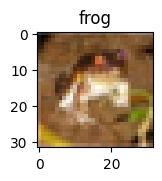

In [14]:
image,label = train_data[0]
image = image.permute(1,2,0) # matplotlib [3,32,32] şeklinde kabul etmiyor [32,32,3] şeklinde kabul ettiği için permute kullandık.
plt.figure(figsize=(1.5,1.5))
plt.imshow(image)
plt.title(class_names[label])

In [15]:
# totensor 0 ile 255 arasındaki bütün rakamları sayıları 255 e böler çünkü büyük rakamlarla hesaplamaları yavaşlatır bilgi kaybıda olmaz
# standardize edilmiş görseller vesaire çok daha hızlı çok daha stabil bir şekilde eğitime tabi tutuluyor.
from torchvision import transforms

In [16]:
transform = transforms.Compose(
    [
          transforms.ToTensor(),
          transforms.Normalize(mean = [0.4914,0.4822,0.4465],std =[0.2470,0.2435,0.2616])
    ]

)

In [17]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    download = True,
    transform = transform,
    target_transform = None
)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download = True,
    transform = transform
)

In [18]:
image,label = train_data[0]

In [19]:
image

tensor([[[-1.0527e+00, -1.3068e+00, -1.1956e+00,  ...,  5.1906e-01,
           4.2380e-01,  3.6029e-01],
         [-1.7354e+00, -1.9895e+00, -1.7037e+00,  ..., -3.6628e-02,
          -1.0013e-01, -5.2505e-02],
         [-1.5926e+00, -1.7354e+00, -1.2115e+00,  ..., -1.1601e-01,
          -8.4258e-02, -2.5890e-01],
         ...,
         [ 1.3129e+00,  1.2018e+00,  1.1541e+00,  ...,  5.5081e-01,
          -1.1004e+00, -1.1480e+00],
         [ 8.6835e-01,  7.5721e-01,  9.6361e-01,  ...,  9.3186e-01,
          -4.4942e-01, -6.7170e-01],
         [ 8.2072e-01,  6.7783e-01,  8.5247e-01,  ...,  1.4399e+00,
           4.0792e-01, -3.6628e-02]],

        [[-9.8178e-01, -1.2395e+00, -1.2072e+00,  ...,  1.4557e-01,
           3.2838e-02,  1.6733e-02],
         [-1.6582e+00, -1.9803e+00, -1.8514e+00,  ..., -5.6305e-01,
          -6.4357e-01, -5.7915e-01],
         [-1.5938e+00, -1.8676e+00, -1.5455e+00,  ..., -6.2747e-01,
          -6.2747e-01, -8.0462e-01],
         ...,
         [ 7.5756e-01,  4

Text(0.5, 1.0, 'frog')

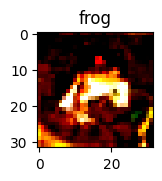

In [20]:
image,label = train_data[0]
image = image.permute(1,2,0) # matplotlib [3,32,32] şeklinde kabul etmiyor [32,32,3] şeklinde kabul ettiği için permute kullandık.
plt.figure(figsize=(1.5,1.5))
plt.imshow(image)
plt.title(class_names[label])

In [21]:
#data loader elimizde bulunan datasetini eğitime hazırlamak için kullanılan bir sınıftır.
from torch.utils.data import DataLoader

In [22]:
BATCH_SIZE = 32
train_data_loader = DataLoader(dataset=train_data,batch_size=BATCH_SIZE,shuffle=True) # batchsizelarda 32 ve 128 genelde kulllanılır
test_data_loader = DataLoader(dataset=test_data,batch_size=BATCH_SIZE,shuffle=False)

In [23]:
len(train_data_loader)

1563

In [24]:
len(test_data_loader)

313

In [25]:
# 1563*32 = 50000 1 batch içinde 32 tane görsel var
# 313*32 = 10000

In [26]:
train_data_loader.dataset[0][0].shape # görsellerin şekilleri bozulmadı

torch.Size([3, 32, 32])

In [27]:
# max pool işlemi bittikten sonra bir dense layer olur bu dense layer da standard bir nn dir aslında cnn + 1 1 dediğimizde ann sofmax hesaplanmadan bir linear katmanı var
# bu katmanda flatte layer olarak adlandırılır

In [28]:
flatten_model = nn.Flatten()
first_data = train_data_loader.dataset[0][0]
flattened_data = flatten_model(first_data)

print(first_data.shape)
print(flattened_data.shape)

torch.Size([3, 32, 32])
torch.Size([3, 1024])


In [29]:
class CIFAR10Classifier(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()

    self.layer_stack = nn.Sequential(

            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_units),
            nn.Linear(in_features=hidden_units,out_features=output_shape)
    )

  def forward(self,x):
    return self.layer_stack(x)

In [30]:
first_data.shape # her bir piksel feature ' dır

torch.Size([3, 32, 32])

In [31]:
3 * 32 *32 # 3072 feature var burda ve bunu inputsahpe olarak vermemiz gerekecek.

3072

In [32]:
len(class_names)

10

In [33]:
torch.manual_seed(42)
model_0 = CIFAR10Classifier(input_shape=3072,hidden_units=32,output_shape=len(class_names))

In [34]:
model_0 = torch.compile(model_0)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters() , lr = 0.01)

In [35]:
def calculate_accuracy(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

In [ ]:
torch.manual_seed(42)
epochs = 10
for epoch in range(epochs):
    train_loss = 0

    for batch,(X,y) in enumerate(train_data_loader):
      model_0.train()
      y_pred = model_0(X)
      loss = loss_fn(y_pred,y)
      train_loss+=loss

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if batch % 500 == 0:
        print(f"Batch Number : {batch}")

    train_loss /= len(test_data_loader)

    test_loss = 0
    test_acc = 0

    model_0.eval()
    with torch.inference_mode():
       for X,y in test_data_loader:
          test_pred = model_0(X)
          test_loss = loss_fn(test_pred,y)
          test_acc += calculate_accuracy(y_true=y,y_pred = test_pred.argmax(dim=1))

       test_loss /= len(test_data_loader)
       test_acc /= len(test_data_loader)

    print(f"Train Loss : {train_loss} , Test Loss : {test_loss} , Test Accuracy : {test_acc}")

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss : 12.37153148651123 , Test Loss : 0.009122895076870918 , Test Accuracy : 26.876996805111823
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss : 12.66103744506836 , Test Loss : 0.006705860141664743 , Test Accuracy : 27.90535143769968
Batch Number : 0
Batch Number : 500



KeyboardInterrupt



In [36]:
def evaluate_model_performance(model:torch.nn.Module,data_loader:torch.utils.data.DataLoader,loss_fn:torch.nn.Module,accuracy_function):
        loss = 0
        acc = 0
        model.eval()
        with torch.inference_mode():
              for X,y in data_loader:
                  y_pred = model(X)
                  loss+= loss_fn(y_pred,y)
                  acc += accuracy_function(y_true=y,y_pred = y_pred.argmax(dim=1))

              loss /= len(data_loader)
              acc /= len(data_loader)

        return {"model_name" : model.__class__.__name__,"model_loss" : loss.item(),"model_accuracy" : acc}

In [37]:
model_0_results = evaluate_model_performance(model=model_0,data_loader=test_data_loader,loss_fn=loss_fn,accuracy_function=calculate_accuracy)

In [38]:
model_0_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.3893473148345947,
 'model_accuracy': 8.935702875399361}

In [39]:
class CIFAR10ClassifierNonLinear(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()

    self.layer_stack = nn.Sequential(

            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_shape)
    )

  def forward(self,x):
    return self.layer_stack(x)

In [40]:
torch.manual_seed(42)
model_1 = CIFAR10ClassifierNonLinear(input_shape=3072,hidden_units=32,output_shape=len(class_names))

In [41]:
model_1 = torch.compile(model_1)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters() , lr = 0.01)

In [ ]:
torch.manual_seed(42)
epochs = 10
for epoch in range(epochs):
    train_loss = 0

    for batch,(X,y) in enumerate(train_data_loader):
      model_1.train()
      y_pred = model_1(X)
      loss = loss_fn(y_pred,y)
      train_loss+=loss

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if batch % 500 == 0:
        print(f"Batch Number : {batch}")

    train_loss /= len(test_data_loader)

    test_loss = 0
    test_acc = 0

    model_1.eval()
    with torch.inference_mode():
       for X,y in test_data_loader:
          test_pred = model_1(X)
          test_loss = loss_fn(test_pred,y)
          test_acc += calculate_accuracy(y_true=y,y_pred = test_pred.argmax(dim=1))

       test_loss /= len(test_data_loader)
       test_acc /= len(test_data_loader)

    print(f"Train Loss : {train_loss} , Test Loss : {test_loss} , Test Accuracy : {test_acc}")

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss : 11.799986839294434 , Test Loss : 0.008225400932133198 , Test Accuracy : 28.154952076677315
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss : 11.46314525604248 , Test Loss : 0.011167640797793865 , Test Accuracy : 27.635782747603834
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss : 11.287487983703613 , Test Loss : 0.008529695682227612 , Test Accuracy : 29.273162939297123
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss : 11.040108680725098 , Test Loss : 0.010127350687980652 , Test Accuracy : 28.60423322683706
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss : 10.992380142211914 , Test Loss : 0.010196794755756855 , Test Accuracy : 28.464456869009584
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss : 10.7992658615

In [ ]:
model_1_results = evaluate_model_performance(model=model_1,data_loader=test_data_loader,loss_fn=loss_fn,accuracy_function=calculate_accuracy)

In [ ]:
model_1_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.067331075668335,
 'model_accuracy': 26.976837060702877}

In [ ]:
model_0_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.4222092628479004,
 'model_accuracy': 28.115015974440894}

In [46]:
class CIFAR10ClassifierCNN(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.block_1 = nn.Sequential(

        nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=3,stride=1,padding=1), # kernel size = (3,3) formatında da yazılabilirdi.
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)

    )

    self.block_2 = nn.Sequential(

        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1), # kernel size = (3,3) formatında da yazılabilirdi.
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)

    )

    self.classifer = nn.Sequential(


              nn.Flatten(),
              nn.Linear(in_features=hidden_units*8*8,out_features=output_shape) # burda dense layerda flatten yaptığımız için direk olarak hidden_units veremiyoruz bu yüzden hidden_units * olmalı

    )

  def forward(self,x):
    return self.classifier(self.block_2(self.block_1(x)))

In [47]:
torch.manual_seed(42)

model_2 = CIFAR10ClassifierCNN(input_shape=3,hidden_units=32,output_shape=len(class_names))

In [48]:
model_2

CIFAR10ClassifierCNN(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)

In [49]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(),lr=0.01)

In [50]:
torch.manual_seed(42)
epochs = 10
for epoch in range(epochs):
    train_loss = 0

    for batch,(X,y) in enumerate(train_data_loader):
      model_2.train()
      y_pred = model_2(X)
      loss = loss_fn(y_pred,y)
      train_loss+=loss

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if batch % 500 == 0:
        print(f"Batch Number : {batch}")

    train_loss /= len(test_data_loader)

    test_loss = 0
    test_acc = 0

    model_2.eval()
    with torch.inference_mode():
       for X,y in test_data_loader:
          test_pred = model_2(X)
          test_loss = loss_fn(test_pred,y)
          test_acc += calculate_accuracy(y_true=y,y_pred = test_pred.argmax(dim=1))

       test_loss /= len(test_data_loader)
       test_acc /= len(test_data_loader)

    print(f"Train Loss : {train_loss} , Test Loss : {test_loss} , Test Accuracy : {test_acc}")

AttributeError: 'CIFAR10ClassifierCNN' object has no attribute 'classifier'